<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-20-April-9-2026/Lecture-20_DimensionalityReduction-NeuralTSNE_Solutions-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 20 - Dimensionality Reduction - NeuralTSNE


Import all basic pacakges

In [1]:
!pip install neuraltsne

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.2/522.2 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 76.3 MB/s eta 0:00:00
  Created wheel for lightning-python: filename=lightning_python-1.2.1-py3-none-any.whl size=527626 sha256=d6a935ec3443308d8f657962e51ec63e60349217f49011709f4f98e1dd28b809
  Stored in directory: /root/.cache/pip/wheels/c1/fc/b6/01429707d54cb6d6d4f46a9c157c318bf0711f785671bd24d6
Successfully built lightning-python
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's d

In [1]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Alanine Dipeptide

Here we consider a alanine dipeptide in vacuum that is simple model often used to test methods. It consists of one alanine (ala) residues and capping group. It is conformational dynamics can be understood in terms of the backbond dihedral angles $\Phi$ and $\Psi$.

![Alanine Dipeptide](https://github.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-16-March-24-2026/Ala1.png?raw=true)

We will consider dataset from molecular dynamics simulations, in particular parallel tempering (PT) simulations, that should give correct equilibrium sampling according to the Boltzmann distribution.

The dataset we consider is at different temperatures, 416 K and 576 K. It is from a 100 ns PT simulations where we save variables every 10 ps, so we have 10000 samples.

The variables we consider are the dihedrals, $\Phi$ and $\Psi$, and also the set of all heavy atom distances.

In [2]:
# Download datasets

%%bash
datasets="
colvar.0.data
colvar.1.data
colvar.2.data
colvar.3.data
colvar.HeavyAtoms-Distances.0.data
colvar.HeavyAtoms-Distances.1.data
colvar.HeavyAtoms-Distances.2.data
colvar.HeavyAtoms-Distances.3.data
Temperatures.txt
"

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Lecture-20-April-9-2026/Datasets"

for d in ${datasets}
do
  wget ${url}/${d} &> /dev/null
done

ls

colvar.0.data
colvar.1.data
colvar.2.data
colvar.3.data
colvar.HeavyAtoms-Distances.0.data
colvar.HeavyAtoms-Distances.1.data
colvar.HeavyAtoms-Distances.2.data
colvar.HeavyAtoms-Distances.3.data
sample_data
Temperatures.txt


In [3]:
!cat Temperatures.txt

# Index  T
    0           300.00000 
    1           416.01676
    2           576.89983 
    3           800.00000 


Load data

In [5]:
def get_variables_names_from_header(filename):
  with open(filename, 'r') as f:
    header = f.readline()
    variables = header.split()[2:]
  return variables

In [8]:
data_dih = {}

dih_variables = get_variables_names_from_header("colvar.0.data")

data_dih['300K'] = pd.read_csv("colvar.0.data", header=None, names=dih_variables, sep='\\s+', comment="#")
data_dih['416K'] = pd.read_csv("colvar.1.data", header=None, names=dih_variables, sep='\\s+', comment="#")
data_dih['576K'] = pd.read_csv("colvar.2.data", header=None, names=dih_variables, sep='\\s+', comment="#")
data_dih['800K'] = pd.read_csv("colvar.3.data", header=None, names=dih_variables, sep='\\s+', comment="#")

In [32]:
dist_variables = get_variables_names_from_header("colvar.HeavyAtoms-Distances.0.data")
data_dist = {}

data_dist['300K'] = pd.read_csv("colvar.HeavyAtoms-Distances.0.data", header=None, names=dist_variables, sep='\\s+', comment="#")
data_dist['416K'] = pd.read_csv("colvar.HeavyAtoms-Distances.1.data", header=None, names=dist_variables, sep='\\s+', comment="#")
data_dist['576K'] = pd.read_csv("colvar.HeavyAtoms-Distances.2.data", header=None, names=dist_variables, sep='\\s+', comment="#")
data_dist['800K'] = pd.read_csv("colvar.HeavyAtoms-Distances.3.data", header=None, names=dist_variables, sep='\\s+', comment="#")

,time,phi,psi,theta
0,0.000000,-1.141704,1.082064,-0.210466
1,5.000000,-1.093682,1.075238,-0.001891
2,10.000000,-2.660454,2.694891,0.135193
3,15.000001,-1.225124,2.087589,0.152920
4,20.000001,-1.650727,2.119098,-0.215621
...,...,...,...,...
39996,199980.009499,-2.160246,2.680080,-0.189749
39997,199985.009499,-1.354205,2.630533,-0.556879
39998,199990.009499,-1.030658,0.932295,-0.424351
39999,199995.009499,-1.569521,-3.006828,0.047382


First we consider the dihedral angles

300K


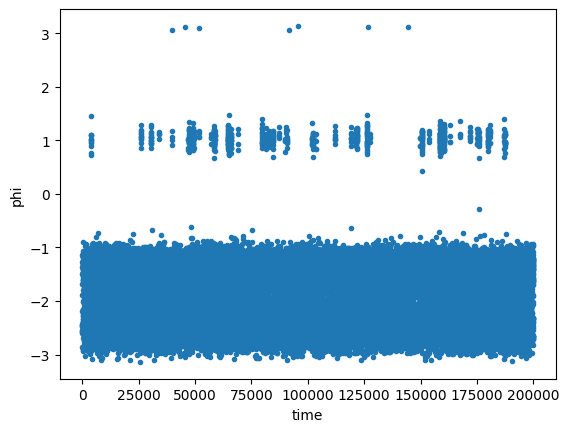

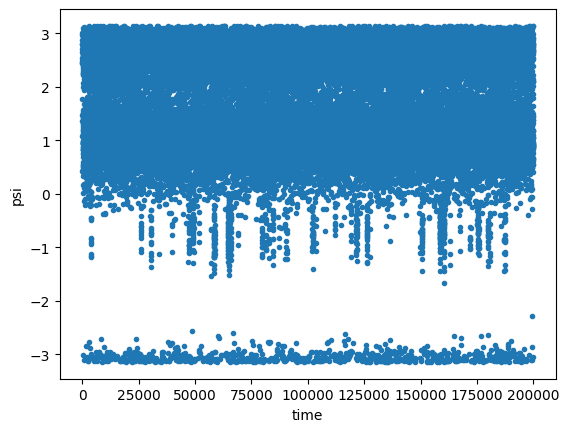

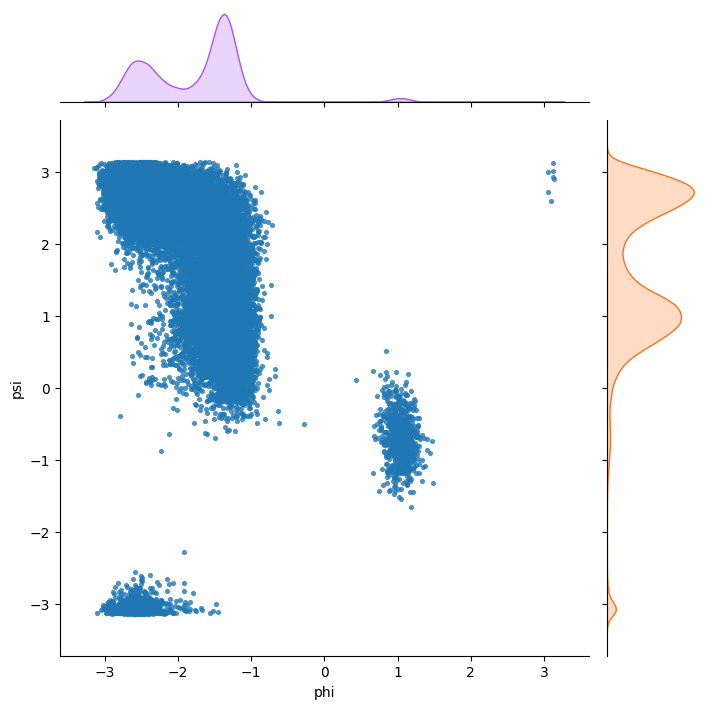

416K


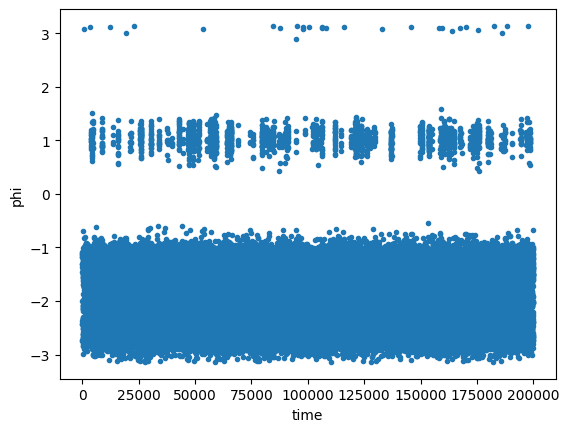

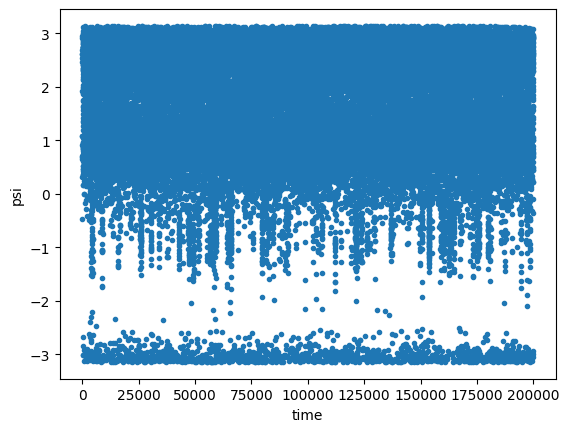

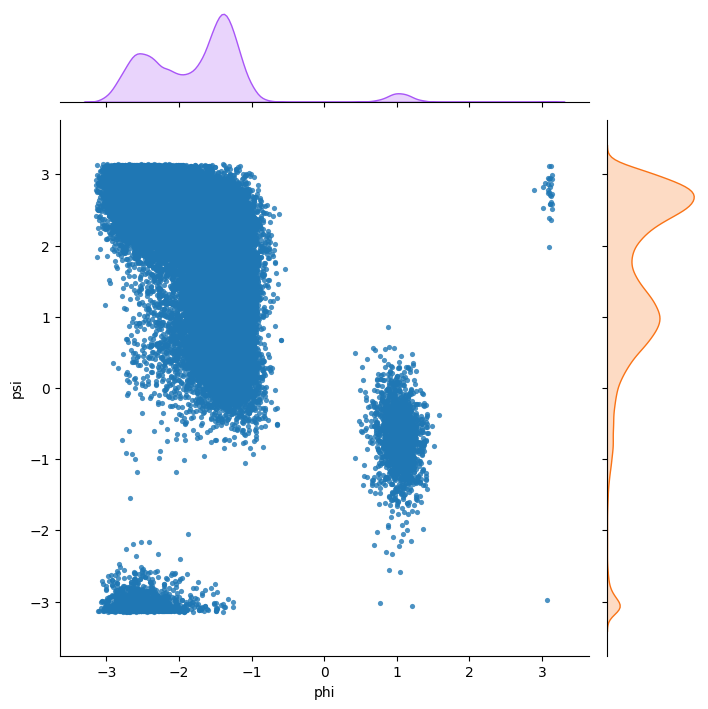

576K


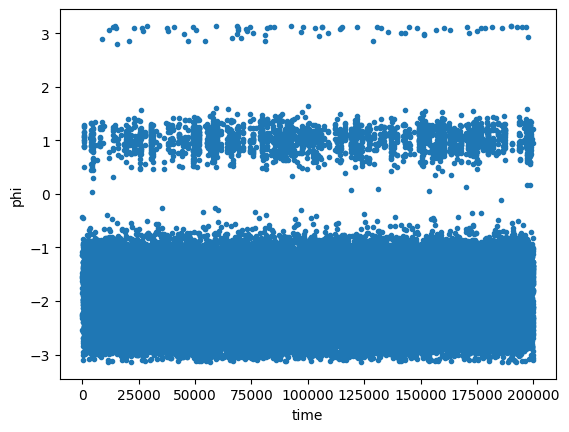

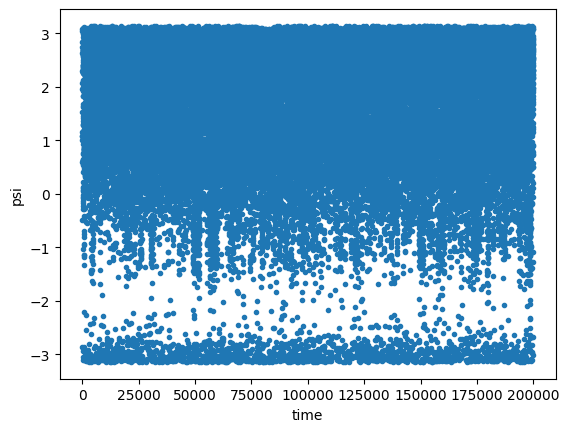

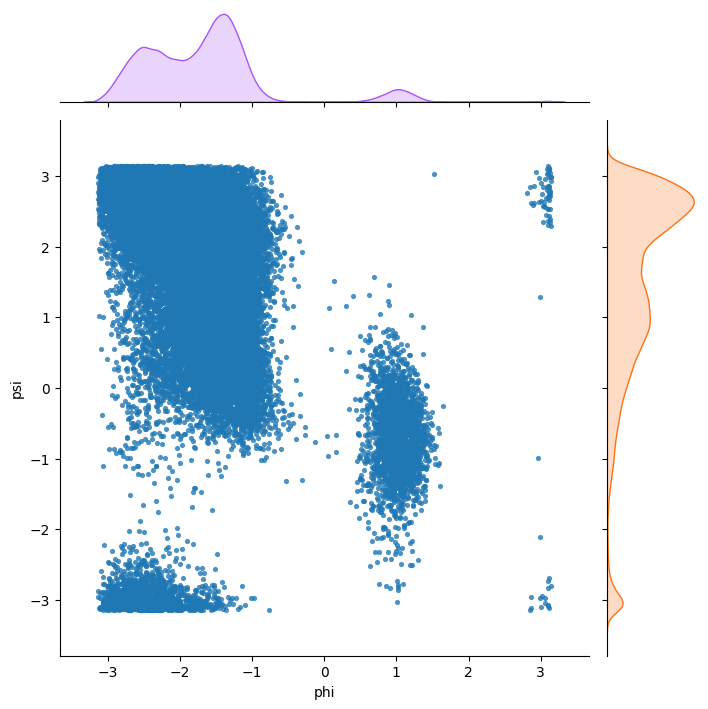

800K


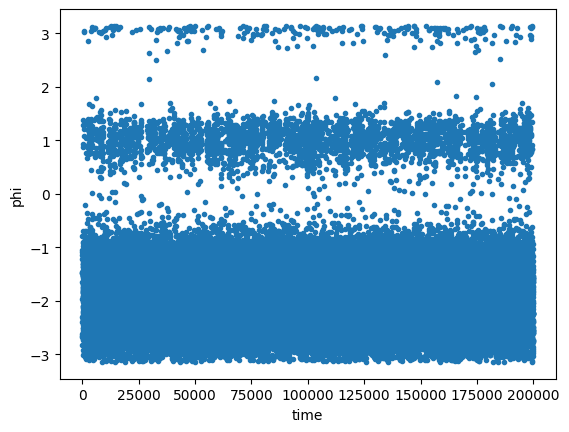

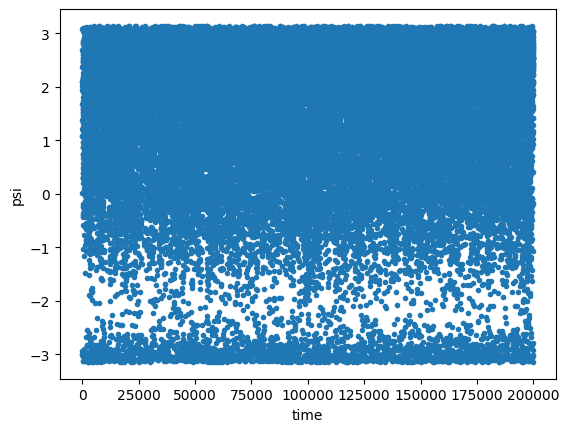

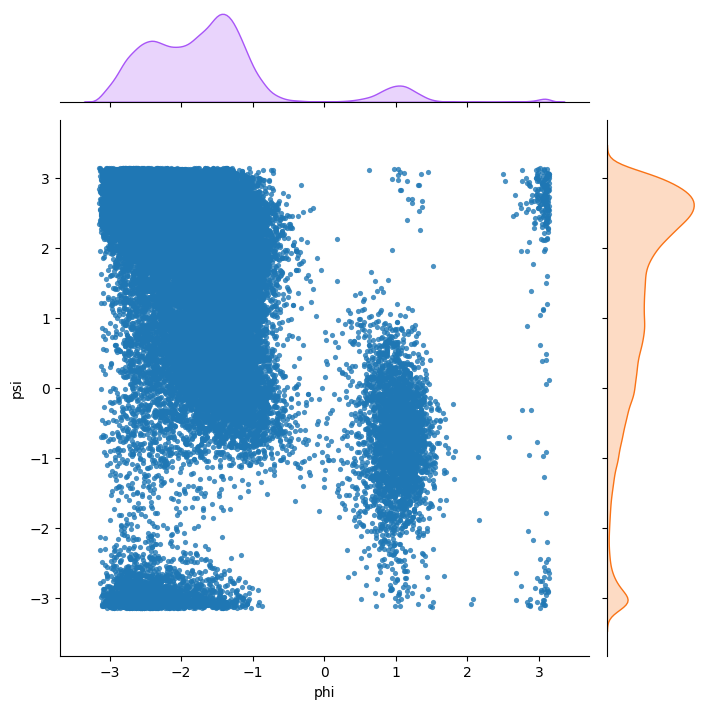

In [13]:
for T in data_dih.keys():
  print(T)
  x_label = 'phi'
  y_label = 'psi'

  t = data_dih[T]['time']
  x = data_dih[T][x_label]
  y = data_dih[T][y_label]


  plt.plot(t, x, '.', label='x')
  plt.xlabel('time')
  plt.ylabel(x_label)
  plt.show()

  plt.plot(t, y, '.', label='y')
  plt.xlabel('time')
  plt.ylabel(y_label)
  plt.show()

  g = sns.JointGrid(height=7, ratio=5)
  ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
  sc = ax_scatter.scatter(x, y, s=14, alpha=0.8, linewidths=0)
  ax_scatter.set_xlabel(x_label)
  ax_scatter.set_ylabel(y_label)
  sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
  sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
  plt.show()

  # g = sns.JointGrid(height=7, ratio=5)
  # ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
  # sns.kdeplot(x=x, y=y,
  #             ax=ax_joint,
  #             bw_adjust=0.6,
  #             fill=True,
  #             levels=8)
  # ax_joint.set_xlabel(x_label)
  # ax_joint.set_ylabel(y_label)
  # sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
  # sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
  # plt.show()



800K
576K
416K
300K


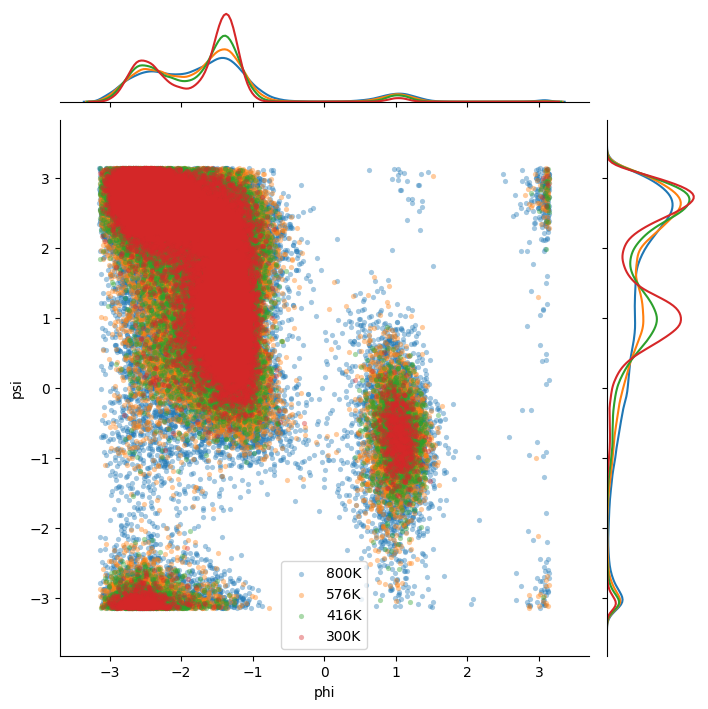

In [23]:
g = sns.JointGrid(height=7, ratio=5)
ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y

for T in ['800K', '576K', '416K', '300K']:
  print(T)
  x_label = 'phi'
  y_label = 'psi'

  t = data_dih[T]['time']
  x = data_dih[T][x_label]
  y = data_dih[T][y_label]




  sc = ax_scatter.scatter(x, y, s=14, alpha=0.4, linewidths=0,label=T)
  ax_scatter.set_xlabel(x_label)
  ax_scatter.set_ylabel(y_label)
  sns.kdeplot(x=x, ax=ax_top, fill=False, bw_adjust=0.6,label=T)
  sns.kdeplot(y=y, ax=ax_right, fill=False, bw_adjust=0.6)
ax_scatter.legend()
plt.show()


  # g = sns.JointGrid(height=7, ratio=5)
  # ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
  # sns.kdeplot(x=x, y=y,
  #             ax=ax_joint,
  #             bw_adjust=0.6,
  #             fill=True,
  #             levels=8)
  # ax_joint.set_xlabel(x_label)
  # ax_joint.set_ylabel(y_label)
  # sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
  # sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
  # plt.show()



300K


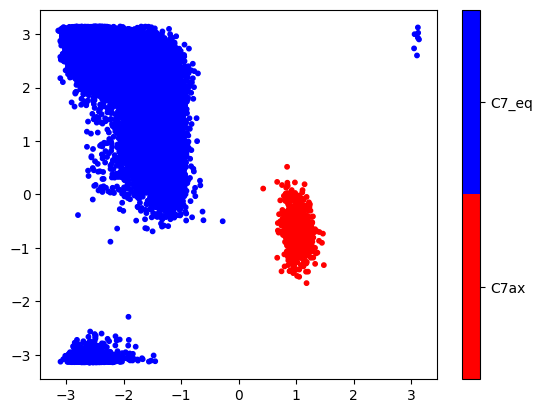

416K


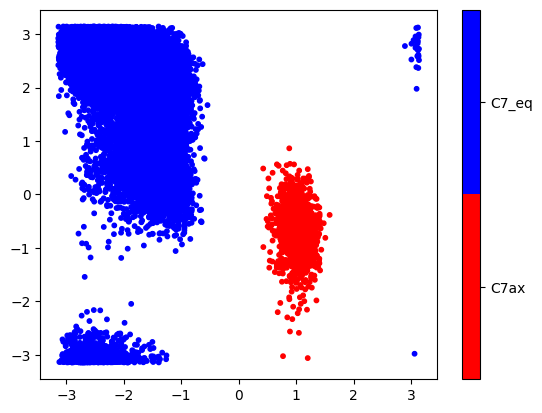

576K


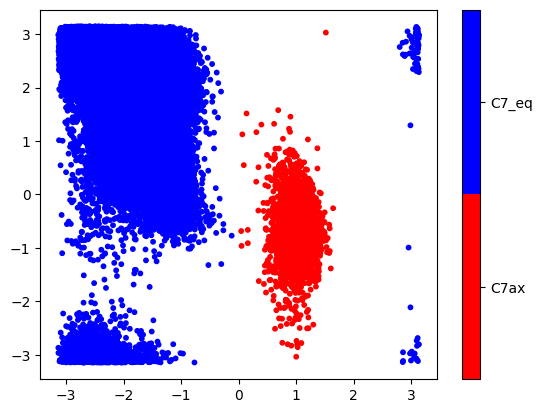

800K


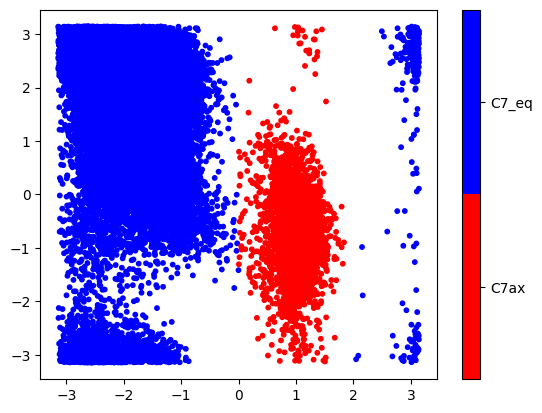

In [24]:
for T in data_dih.keys():
  print(T)
  phi = data_dih[T]['phi'].to_numpy()

  data_dih[T]['C7eq_basin'] = np.where( (phi > 0) & (phi < 2) ,0 , 1)
  data_dih[T]['C7eq_bool'] = np.where( (phi > 0) & (phi < 2) ,False , True)
  data_dih[T]['C7ax_bool'] = np.where( (phi > 0) & (phi < 2) ,True , False)

  import matplotlib.colors as mcolors
  cmap = mcolors.ListedColormap(['red', 'blue'])
  plt.scatter(data_dih[T]['phi'], data_dih[T]['psi'],c=data_dih[T]['C7eq_basin'],s=10, cmap=cmap)
  cbar = plt.colorbar(ticks=[0.25,0.75])
  cbar.ax.set_yticklabels(['C7ax', 'C7_eq'])
  plt.show()

## Distances

## NeuralTSNE

Here we are going to use the [NeuralTSNE code](https://pubs.acs.org/doi/10.1021/acs.jcim.5c01107) that implements t-SNE using a neural network.

Based on [example](https://github.com/NeuralTSNE/NeuralTSNE/blob/main/examples/example-adp.ipynb) from the NeuralTSNE code.

In [25]:
import torch
import NeuralTSNE as ntsne

from torch.utils.data import TensorDataset, random_split
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer, seed_everything

torch.set_float32_matmul_precision("high")

In [26]:
# Check if CUDA is available
print(torch.cuda.is_available())  # True = GPU available

# See which device you're on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # 'cuda' or 'cpu'

# Get GPU name (if available)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # e.g. 'NVIDIA GeForce RTX 3090'
    print(torch.cuda.device_count())      # Number of GPUs

True
cuda
NVIDIA A100-SXM4-40GB
1


## Training at 300K

Here we train the NN at 300 K

In [116]:
T = '300K'

In [169]:
stride=1
distances = data_dist[T].drop(columns=['time']).to_numpy()[::stride]
from sklearn.preprocessing import StandardScaler

scaled_distances = StandardScaler().fit_transform(distances)

X = torch.tensor(scaled_distances, dtype=torch.float32)
dataset = TensorDataset(X)

valid = 0.2
n = len(dataset)
n_train = int((1.0 - valid) * n)
n_valid = n - n_train
train_dataset, valid_dataset = random_split(dataset, [n_train, n_valid])

In [170]:
print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(valid_dataset))

Number of training samples: 32000
Number of validation samples: 8001


In [171]:
print(distances.shape)

(40001, 45)


In [172]:
initial_features=distances.shape[1]

nn_multipliers = [0.75, 0.75, 0.75]
model = ntsne.TSNE.NeuralNetwork.NeuralNetwork(initial_features=initial_features, n_components=2, multipliers=nn_multipliers)

In [173]:
model

NeuralNetwork(
  (sequential_stack): Sequential(
    (0): Linear(in_features=45, out_features=33, bias=True)
    (ReLu0): ReLU()
    (1): Linear(in_features=33, out_features=33, bias=True)
    (ReLu1): ReLU()
    (2): Linear(in_features=33, out_features=33, bias=True)
    (ReLu2): ReLU()
    (3): Linear(in_features=33, out_features=2, bias=True)
  )
)

In [174]:
param_tsne = ntsne.TSNE.ParametricTSNE.ParametricTSNE(
    loss_fn="kl_divergence",
    perplexity=30,
    batch_size=500,
    early_exaggeration_epochs=0,
    early_exaggeration_value=0,
    max_iterations=600,
    model=model
)

In [175]:
from lightning.pytorch.loggers import CSVLogger
logger = CSVLogger(save_dir="./")

seed_everything(seed=42, workers=True)

early_stopping = EarlyStopping(monitor="val_loss", min_delta=1e-6, patience=10)

trainer = Trainer(
    enable_progress_bar=False,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    log_every_n_steps=32,
    max_epochs=param_tsne.max_iterations,
    callbacks=[early_stopping],
    default_root_dir=".",
    deterministic=True, # seed,
    logger=logger
)



INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [176]:
reducer = ntsne.TSNE.Modules.DimensionalityReduction(
    tsne=param_tsne,
    shuffle=True,
    optimizer="adam",
    lr=1e-3
)

In [177]:
train_dataloader, _ = param_tsne.create_dataloaders(train_dataset, None)
valid_dataloader, _ = param_tsne.create_dataloaders(valid_dataset, None)

full_dataloader, _ = param_tsne.create_dataloaders(dataset, None)

In [178]:
trainer.fit(reducer, train_dataloaders=train_dataloader, val_dataloaders=[valid_dataloader])



INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ NeuralNetwork │  3.8 K │ train │     0 │
└───┴───────┴───────────────┴────────┴───────┴───────┘

Trainable params: 3.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
Calculating P: 100%|██████████| 16/16 [00:20<00:00,  1.30s/batch]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
Calculating P: 100%|██████████| 64/64 [01:24<00:00,  1.32s/batch]


In [179]:
!ls lightning_logs

version_0  version_2  version_4  version_6
version_1  version_3  version_5  version_7


In [162]:
!ls lightning_logs/version_1

checkpoints  metrics.csv


In [180]:
# to obtain the training curves
run_number = 7
log = pd.read_csv("lightning_logs/version_" + str(run_number) + "/metrics.csv")

In [165]:
log

,epoch,step,train_loss_epoch,train_loss_step,val_loss_epoch,val_loss_step
0,0.0,31,NaN,2.05989,NaN,NaN
1,NaN,0,NaN,NaN,NaN,2.037719
2,NaN,1,NaN,NaN,NaN,2.047091
3,NaN,2,NaN,NaN,NaN,2.034053
4,NaN,3,NaN,NaN,NaN,2.034029
...,...,...,...,...,...,...
1887,NaN,1373,NaN,NaN,NaN,1.508365
1888,NaN,1374,NaN,NaN,NaN,1.538051
1889,NaN,1375,NaN,NaN,NaN,1.493062
1890,171.0,5503,NaN,NaN,1.506876,NaN


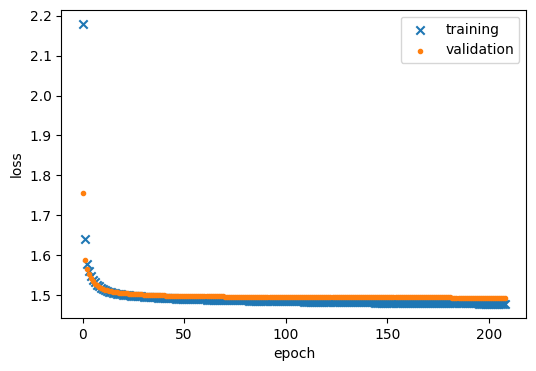

In [181]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.scatter(log['epoch'], log['train_loss_epoch'], label='training', marker='x')
ax.scatter(log['epoch'], log['val_loss_epoch'], label='validation', marker='.')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')

plt.legend()

In [182]:
Z = trainer.predict(reducer, full_dataloader)
Z = np.concatenate(Z, axis=0)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


In [184]:
Z

array([[ 3.7943976 ,  4.104989  ],
       [ 0.96935636,  0.38384587],
       [ 3.8482084 ,  0.88802826],
       ...,
       [ 5.00506   ,  6.1473646 ],
       [ 7.010174  ,  5.345392  ],
       [-1.7658919 , -7.9015694 ]], shape=(40001, 2), dtype=float32)

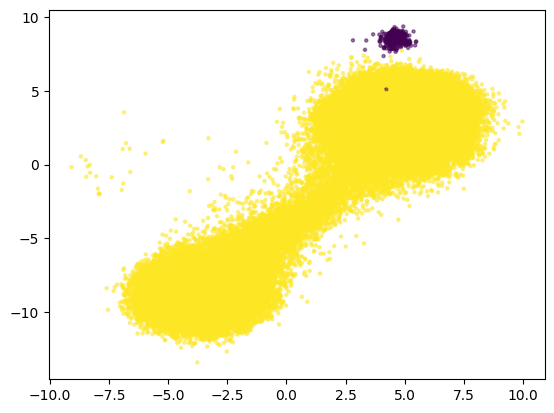

In [183]:
plt.scatter(Z[:, 0], Z[:, 1], c=data_dih[T]['C7eq_basin'].iloc[::stride], s=5, alpha=0.5)
plt.show()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


300K


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


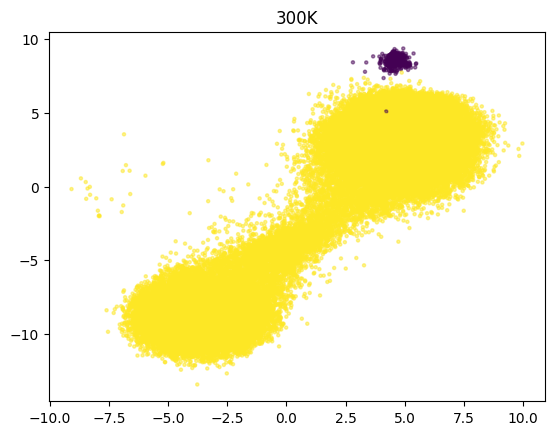

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


416K


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


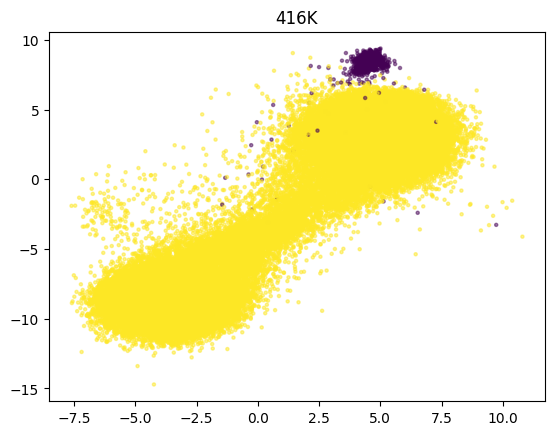

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


576K


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


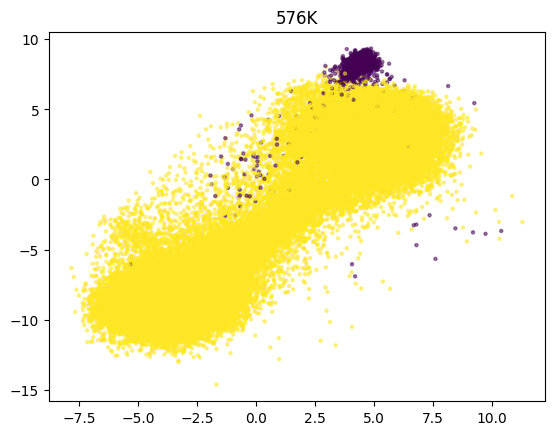

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


800K


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


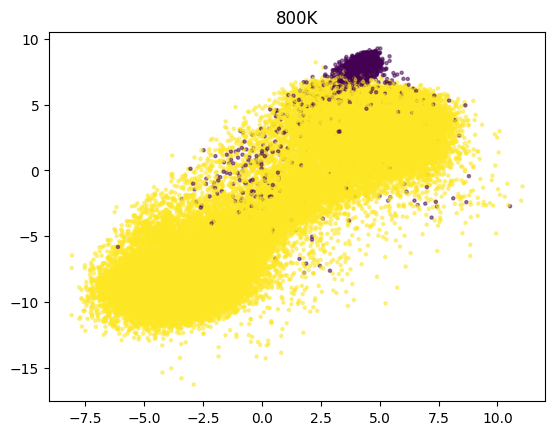

In [188]:
for T in data_dih.keys():
  print(T)
  stride=1
  distances = data_dist[T].drop(columns=['time']).to_numpy()[::stride]
  from sklearn.preprocessing import StandardScaler

  scaled_distances = StandardScaler().fit_transform(distances)

  X = torch.tensor(scaled_distances, dtype=torch.float32)
  dataset = TensorDataset(X)

  full_dataloader_416K, _ = param_tsne.create_dataloaders(dataset, None)

  Z = trainer.predict(reducer, full_dataloader_416K)
  Z = np.concatenate(Z, axis=0)

  plt.scatter(Z[:, 0], Z[:, 1], c=data_dih[T]['C7eq_basin'].iloc[::stride], s=5, alpha=0.5)
  plt.title(T)
  plt.show()